# Zara Analytics

## Imports

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# Statistical analysis
import scipy.stats as stats

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestRegressor

#Fonts
plt.rcParams["font.family"] = "Verdana"


## Dataset

In [2]:
# Dataset loading
df = pd.read_csv("../data/zara_sales.csv", sep= ";")

## Exploration

### Head

In [3]:
# The first few rows of the DataFrame
df.head()

,Product ID,Product Position,Promotion,Product Category,Seasonal,Sales Volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


### Info

In [4]:
# DataFrame information
df.info ()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20252 entries, 0 to 20251
Data columns (total 17 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Product ID        20252 non-null  int64  
 1   Product Position  20252 non-null  object 
 2   Promotion         20252 non-null  object 
 3   Product Category  20252 non-null  object 
 4   Seasonal          20252 non-null  object 
 5   Sales Volume      20252 non-null  int64  
 6   brand             20252 non-null  object 
 7   url               20252 non-null  object 
 8   name              20251 non-null  object 
 9   description       20250 non-null  object 
 10  price             20252 non-null  float64
 11  currency          20252 non-null  object 
 12  terms             20252 non-null  object 
 13  section           20252 non-null  object 
 14  season            20252 non-null  object 
 15  material          20252 non-null  object 
 16  origin            20252 non-null  object

### Numerical

In [5]:
# Summary statistics for numerical columns
df.describe()

,Product ID,Sales Volume,price
count,20252.000000,20252.000000,20252.000000
mean,208931.432303,1097.400454,41.949061
std,8961.076507,298.234609,23.380960
min,110075.000000,518.000000,12.000000
25%,204442.750000,849.000000,23.950000
50%,209505.500000,990.000000,35.950000
75%,214568.250000,1364.250000,53.950000
max,219631.000000,1940.000000,134.990000


### Categorical

In [6]:
# Summary statistics for categorical columns
df.describe(include='object')

,Product Position,Promotion,Product Category,Seasonal,brand,url,name,description,currency,terms,section,season,material,origin
count,20252,20252,20252,20252,20252,20252,20251,20250,20252,20252,20252,20252,20252,20252
unique,3,2,1,2,1,228,17215,221,1,5,2,4,11,12
top,Aisle,No,clothing,No,Zara,https://www.zara.com/us/en/knit-sweater-with-r...,PLAID OVERSHIRT,Varsity jacket with elastic collar and long sl...,USD,jackets,WOMAN,Autumn,Cotton,China
freq,7810,11812,20252,10136,20252,187,8,333,20252,11232,13254,7665,3851,4026


## First Cleaning

### Columns

In [7]:
# Columns names
df.columns

Index(['Product ID', 'Product Position', 'Promotion', 'Product Category',
       'Seasonal', 'Sales Volume', 'brand', 'url', 'name', 'description',
       'price', 'currency', 'terms', 'section', 'season', 'material',
       'origin'],
      dtype='object')

In [8]:
# Standardize column names 
df.columns = ( df.columns .str.lower() .str.strip() .str.replace(' ', '_') )

In [9]:
# Check the updated column names
df.head()

,product_id,product_position,promotion,product_category,seasonal,sales_volume,brand,url,name,description,price,currency,terms,section,season,material,origin
0,185102,Aisle,Yes,clothing,Yes,1243,Zara,https://www.zara.com/us/en/basic-puffer-jacket...,BASIC PUFFER JACKET,Puffer jacket made of tear-resistant ripstop f...,78.99,USD,jackets,MAN,Winter,Polyester,Brazil
1,188771,Aisle,Yes,clothing,No,1429,Zara,https://www.zara.com/us/en/tuxedo-jacket-p0889...,TUXEDO JACKET,Straight fit blazer. Pointed lapel collar and ...,14.99,USD,jackets,MAN,Autumn,Cotton,Turkey
2,180176,End-cap,Yes,clothing,Yes,1168,Zara,https://www.zara.com/us/en/slim-fit-suit-jacke...,SLIM FIT SUIT JACKET,Slim fit jacket. Notched lapel collar. Long sl...,71.95,USD,jackets,WOMAN,Autumn,Polyester,Morocco
3,112917,Aisle,Yes,clothing,No,1348,Zara,https://www.zara.com/us/en/stretch-suit-jacket...,STRETCH SUIT JACKET,Slim fit jacket made of viscose blend fabric. ...,30.99,USD,jackets,MAN,Spring,Polyester,China
4,192936,End-cap,Yes,clothing,Yes,1602,Zara,https://www.zara.com/us/en/double-faced-jacket...,DOUBLE FACED JACKET,Jacket made of faux leather faux shearling wit...,22.99,USD,jackets,WOMAN,Winter,Wool Blend,China


### Correction

In [10]:
# Correction terms
df["terms"] = df["terms"].str.capitalize()

In [11]:
# Correction section
df["section"] = df["section"].str.capitalize()

In [12]:
# Correction name
df["name"] = df["name"].str.title()

### Drop

In [13]:
# Drop unnecessary columns
df = df.drop(columns=['product_id', 'product_category', 'url', 'description', 'currency'])

In [14]:
# Drop unnecessary columns
df = df.drop(columns=['brand'])

In [15]:
# Check the cleaned DataFrame
df.head()

,product_position,promotion,seasonal,sales_volume,name,price,terms,section,season,material,origin
0,Aisle,Yes,Yes,1243,Basic Puffer Jacket,78.99,Jackets,Man,Winter,Polyester,Brazil
1,Aisle,Yes,No,1429,Tuxedo Jacket,14.99,Jackets,Man,Autumn,Cotton,Turkey
2,End-cap,Yes,Yes,1168,Slim Fit Suit Jacket,71.95,Jackets,Woman,Autumn,Polyester,Morocco
3,Aisle,Yes,No,1348,Stretch Suit Jacket,30.99,Jackets,Man,Spring,Polyester,China
4,End-cap,Yes,Yes,1602,Double Faced Jacket,22.99,Jackets,Woman,Winter,Wool Blend,China


## Exploratory Data Analysis (EDA)

### Null

In [16]:
# Check for missing values
df.isnull().sum()

product_position    0
promotion           0
seasonal            0
sales_volume        0
name                1
price               0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

### Duplicate

In [17]:
# Check for duplicate rows
df.duplicated().sum()

np.int64(0)

### Outliers 

#### Sales Volume Outliers

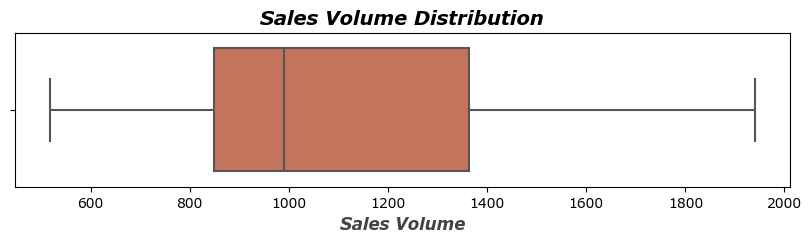

In [18]:
# Sales Volume Distribution

plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["sales_volume"],
    color='#D46A4C',
    linewidth=1.5
)

plt.title(
    "Sales Volume Distribution",
    fontsize=14,
    fontweight="bold",
    style="italic",
)

plt.xlabel(
    "Sales Volume", 
    fontsize=12, 
    fontweight="bold",
    style="italic",
    color="#434343"
)

plt.show()

#### Price Outliers

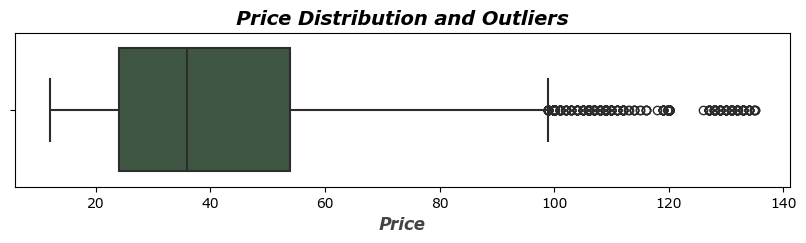

In [19]:
# Price Distribution and Outliers

plt.figure(figsize=(10,2))

sns.boxplot(
    x=df["price"],
    color= "#3A5A40",
    linewidth=1.5
)

plt.title(
    "Price Distribution and Outliers",
    fontsize=14,
    fontweight="bold",
    style="italic",
)

plt.xlabel(
    "Price", 
    fontsize=12, 
    fontweight="bold",
    style="italic",
    color="#434343"
)

plt.show()

### Distribution

#### Price Distribution 

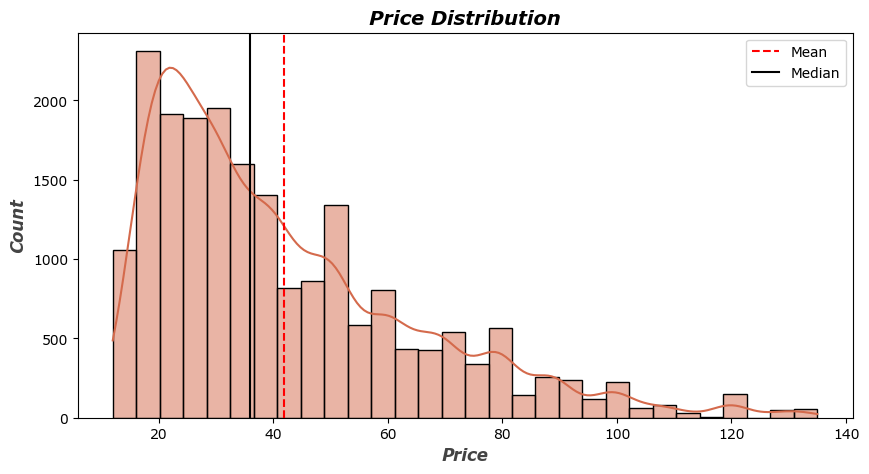

In [20]:
# The distribution of price with a histogram
plt.figure(figsize=(10,5))

sns.histplot(
    df["price"],
    bins=30,
    kde=True,
    color='#D46A4C'
)

plt.title(
    "Price Distribution",
    fontsize=14,
    fontweight="bold",
    style="italic"
)

plt.axvline(
    df["price"].mean(),
    color="red",
    linestyle="--",
    label="Mean"
)

plt.axvline(
    df["price"].median(),
    color="black",
    linestyle="-",
    label="Median"
)

plt.legend()
plt.xlabel(
    "Price", 
    fontsize=12, 
    fontweight="bold",
    style="italic",
    color="#434343"
)

plt.ylabel(
    "Count", 
    fontsize=12, 
    fontweight="bold",
    style="italic",
    color="#434343"
)

plt.show()

#### Sales Volume Distribution

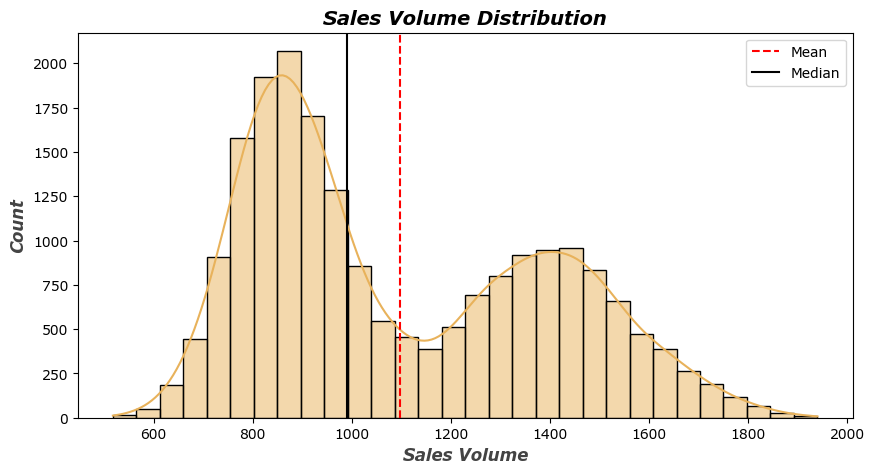

In [21]:
# The Distribution of Sales Volume

plt.figure(figsize=(10,5))

sns.histplot(
    df["sales_volume"], 
    kde=True,
    bins=30,
    color='#E8B25B'
)

plt.title(
    "Sales Volume Distribution",
    fontsize=14,
    fontweight="bold",
    style="italic"

)

plt.axvline(
    df["sales_volume"].mean(),
    color="red",
    linestyle="--",
    label="Mean"
)

plt.axvline(
    df["sales_volume"].median(),
    color="black",
    linestyle="-",
    label="Median"
)

plt.legend()
plt.xlabel(
    "Sales Volume", 
    fontsize=12, 
    fontweight="bold",
    style="italic",
    color="#434343"
)

plt.ylabel(
    "Count", 
    fontsize=12, 
    fontweight="bold",
    style="italic",
    color="#434343"
)

plt.show()

### Relationship between Price and Sales Volume

/Users/noeliafranciscodemoya/Desktop/Portafolio/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: divide by zero encountered in matmul
  return _core_matmul(x1, x2)
/Users/noeliafranciscodemoya/Desktop/Portafolio/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: overflow encountered in matmul
  return _core_matmul(x1, x2)
/Users/noeliafranciscodemoya/Desktop/Portafolio/.venv/lib/python3.9/site-packages/numpy/linalg/_linalg.py:3220: RuntimeWarning: invalid value encountered in matmul
  return _core_matmul(x1, x2)


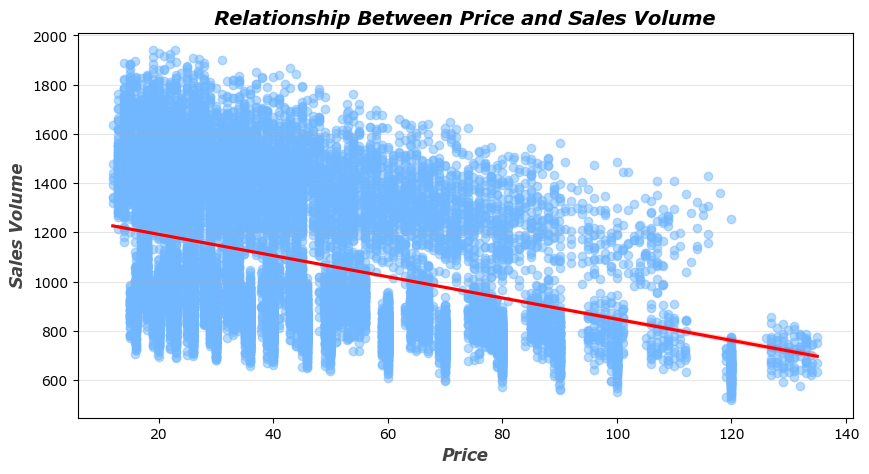

In [22]:
# Relationship between price and Sales Volume with a scatter plot and regression line.
plt.figure(figsize=(10,5))

sns.regplot(
    data=df,
    x="price",
    y="sales_volume",
    scatter_kws={"alpha":0.5},
    color='#70B7FF',
    line_kws={"color":"red"}
)

plt.title(
    "Relationship Between Price and Sales Volume",
    fontsize=14,
    fontweight="bold",
    style="italic"
)

plt.xlabel(
    "Price", 
    fontsize=12, 
    fontweight="bold",
    style="italic",
    color="#434343"
)
plt.ylabel(
    "Sales Volume", 
    fontsize=12, 
    fontweight="bold",
    style="italic",
    color="#434343"
)

plt.grid(axis="y", alpha=0.3)

plt.show()


### Season and Promotion

In [23]:
# Crosstab of season and promotion
pd.crosstab(df["season"], df["promotion"])

promotion,No,Yes
season,,
Autumn,4470,3195
Spring,2619,1918
Summer,1667,1239
Winter,3056,2088


## Final Cleaning

### Null

In [24]:
# Check for missing values
df.isnull().sum()

product_position    0
promotion           0
seasonal            0
sales_volume        0
name                1
price               0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

In [25]:
# Drop rows with missing values in the 'name' column
df = df.dropna(subset=['name'])

In [26]:
# Check 
df.isnull().sum()

product_position    0
promotion           0
seasonal            0
sales_volume        0
name                0
price               0
terms               0
section             0
season              0
material            0
origin              0
dtype: int64

### Price Standardization

In [27]:
# Minimum and maximum price
print("min_price:", df['price'].min())
print("max_price:", df['price'].max())

min_price: 12.0
max_price: 134.99


In [28]:
# Define price bins and labels
bins = [0, 25, 50, 75, 200]
labels = ['Low', 'Medium', 'High', 'Premium']

df['price_range'] = pd.cut(df['price'], bins=bins, labels=labels)


In [29]:
# Check the distribution of price ranges
df['price_range'].value_counts()

price_range
Medium     8946
Low        5761
High       3393
Premium    2151
Name: count, dtype: int64

## Sales & Business Performance


### Products

#### Which categories generate the most sales and revenue?

In [30]:
# Average sales_volume by price_range
df.groupby("terms")["sales_volume"].sum().sort_values(ascending=False)

terms
Jackets     12347354
Sweaters     3598743
T-shirts     2879378
Shoes        2676982
Jeans         721308
Name: sales_volume, dtype: int64

In [31]:
# Calculate revenue and average revenue by terms    
df["revenue"] = df["price"] * df["sales_volume"]
df.groupby("terms")["revenue"].sum().sort_values(ascending=False)

terms
Jackets     4.870467e+08
Sweaters    1.428703e+08
T-shirts    1.182230e+08
Shoes       1.070952e+08
Jeans       2.934775e+07
Name: revenue, dtype: float64

####  Which products perform best and worst in terms of sales?

In [32]:
# Top 5 products with the highest sales_volume
df.nlargest(5, "sales_volume")

,product_position,promotion,seasonal,sales_volume,name,price,terms,section,season,material,origin,price_range,revenue
5100,Front of Store,Yes,Yes,1940,Tailored Colorblock Knit Crop Sweater Navy,18.99,T-shirts,Woman,Summer,Cotton,Portugal,Low,36840.60
8106,End-cap,Yes,No,1940,Slim Boxy Fit Denim Jacket,22.95,Shoes,Woman,Winter,Polyester,Bangladesh,Low,44523.00
4581,Aisle,Yes,Yes,1929,Knit Double Faced Jacket Ecru,19.99,Shoes,Woman,Winter,Wool,Portugal,Low,38560.71
15174,Front of Store,Yes,Yes,1926,Relaxed Zippered Jacket Ivory,22.00,T-shirts,Woman,Summer,Linen,Spain,Low,42372.00
9982,Front of Store,Yes,No,1917,Ribbed 100% Wool Suit Jacket Grey,21.00,Jackets,Woman,Winter,Wool Blend,Turkey,Low,40257.00


In [33]:
# Top 5 products with the lowest sales_volume
df.nsmallest(5, "sales_volume")

,product_position,promotion,seasonal,sales_volume,name,price,terms,section,season,material,origin,price_range,revenue
7585,Aisle,No,No,518,Double-Breasted Faux Leather Oversized Jacket ...,119.95,Shoes,Man,Autumn,Polyester,Vietnam,Premium,62134.10
13475,Aisle,No,No,528,Slim Textured Jacket White,119.99,Jackets,Man,Autumn,Wool,Turkey,Premium,63354.72
11524,Front of Store,No,No,533,Stretch Jacquard Denim Jacket Stone,119.00,Jackets,Man,Autumn,Cotton,Spain,Premium,63427.00
12896,End-cap,No,No,534,Belted Acid Wash Denim Jacket,119.99,Shoes,Man,Autumn,Wool,Bangladesh,Premium,64074.66
16466,Aisle,No,No,539,Pleated Textured Weave Overshirt Charcoal,119.99,Sweaters,Man,Autumn,Cotton,Brazil,Premium,64674.61


#### Does product positioning affect sales?

In [34]:
# Average sales_volume by product_position
df.groupby("product_position")["sales_volume"].mean()

product_position
Aisle             1090.427401
End-cap           1100.505596
Front of Store    1103.361175
Name: sales_volume, dtype: float64

### Seasons

#### Which seasons generate the highest sales volume?

In [35]:
# Average sales_volume by season
df.groupby("season")["sales_volume"].sum().sort_values(ascending=False)

season
Autumn    7993214
Winter    6042207
Spring    4745927
Summer    3442417
Name: sales_volume, dtype: int64

### Promotion

#### Do promotions increase sales?

In [36]:
# Average sales_volume by promotion
df.groupby("promotion")["sales_volume"].mean()

promotion
No      872.384133
Yes    1412.326540
Name: sales_volume, dtype: float64

####  Which categories respond best to promotions?

In [37]:
# Average sales_volume by terms and promotion
df.groupby(["terms", "promotion"])["sales_volume"].mean()

terms     promotion
Jackets   No            873.119988
          Yes          1414.176709
Jeans     No            872.829082
          Yes          1420.071161
Shoes     No            869.246735
          Yes          1408.003988
Sweaters  No            872.975282
          Yes          1414.137536
T-shirts  No            871.416826
          Yes          1404.015785
Name: sales_volume, dtype: float64

### Prince

#### Is there a relationship between price and sales volume?

In [38]:
# Correlation between price and sales_volume
df[["price", "sales_volume"]].corr()

,price,sales_volume
price,1.000000,-0.337836
sales_volume,-0.337836,1.000000


#### Which price range generates the highest sales and revenue?

In [39]:
# Calculate total revenue by price range
sales_by_range = (
    df.groupby("price_range")["sales_volume"]
    .sum()
    .sort_values(ascending=False)
)

print(sales_by_range)

price_range
Medium     9802427
Low        6974120
High       3544121
Premium    1903097
Name: sales_volume, dtype: int64


/var/folders/kw/s6dw9bv10xjcx4tr85g5cjt00000gn/T/ipykernel_3450/1479081736.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_range")["sales_volume"]


In [40]:
# Calculate total revenue by price range
revenue_by_range = (
    df.groupby("price_range")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

print(revenue_by_range) 

price_range
Medium     3.550596e+08
High       2.180360e+08
Premium    1.736047e+08
Low        1.378828e+08
Name: revenue, dtype: float64


/var/folders/kw/s6dw9bv10xjcx4tr85g5cjt00000gn/T/ipykernel_3450/1556223925.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("price_range")["revenue"]


### Material

#### Which materials perform best commercially?

In [41]:
# Total sales_volume by material
df.groupby("material")["sales_volume"].sum().sort_values(ascending=False)

material
Wool           4206508
Cotton         4202312
Wool Blend     3730913
Polyester      2991266
Linen          2840920
Denim          1099805
Viscose        1074996
Acrylic         986066
Linen Blend     908069
Satin           142384
Silk             40526
Name: sales_volume, dtype: int64

In [42]:
# Total revenue by material
df.groupby("material")["revenue"].sum().sort_values(ascending=False)

material
Wool           1.702277e+08
Cotton         1.689832e+08
Wool Blend     1.466085e+08
Polyester      1.173959e+08
Linen          1.157723e+08
Denim          4.228812e+07
Viscose        4.182906e+07
Acrylic        3.895475e+07
Linen Blend    3.566123e+07
Satin          5.167376e+06
Silk           1.694855e+06
Name: revenue, dtype: float64

## Clean CSV 

In [43]:
df.to_csv("zara_analytics_clean.csv", index=False)

## Predictive Analytics

### Dataset (Clean)

In [44]:
# Load the cleaned dataset
df = pd.read_csv("../zara_exploration_and_analytics/zara_analytics_clean.csv", sep= ",")

### Explotariton and Clean

In [45]:
# Check the cleaned DataFrame
df.head()

,product_position,promotion,seasonal,sales_volume,name,price,terms,section,season,material,origin,price_range,revenue
0,Aisle,Yes,Yes,1243,Basic Puffer Jacket,78.99,Jackets,Man,Winter,Polyester,Brazil,Premium,98184.57
1,Aisle,Yes,No,1429,Tuxedo Jacket,14.99,Jackets,Man,Autumn,Cotton,Turkey,Low,21420.71
2,End-cap,Yes,Yes,1168,Slim Fit Suit Jacket,71.95,Jackets,Woman,Autumn,Polyester,Morocco,High,84037.60
3,Aisle,Yes,No,1348,Stretch Suit Jacket,30.99,Jackets,Man,Spring,Polyester,China,Medium,41774.52
4,End-cap,Yes,Yes,1602,Double Faced Jacket,22.99,Jackets,Woman,Winter,Wool Blend,China,Low,36829.98


### K-Means Clustering

#### Can we segment products by price and sales using clustering?

In [46]:
# Clustering analysis using K-Means
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Prepare the data for clustering
X = df[["price", "sales_volume"]]

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

# Analyze the clusters
df.groupby("Cluster")[["price", "sales_volume"]].mean()

/Users/noeliafranciscodemoya/Desktop/Portafolio/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/noeliafranciscodemoya/Desktop/Portafolio/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/noeliafranciscodemoya/Desktop/Portafolio/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/noeliafranciscodemoya/Desktop/Portafolio/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: divide by zero encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/noeliafranciscodemoya/Desktop/Portafolio/.venv/lib/python3.9/site-packages/sklearn/cluster/_kmeans.py:237: RuntimeWarning: overflow encountered in matmul
  current_pot = closest_dist_sq @ sample_weight
/Users/noeliafranciscodemoya/Desktop/Portafoli

,price,sales_volume
Cluster,,
0,79.736175,896.892183
1,31.944716,1447.084464
2,32.791837,906.649978


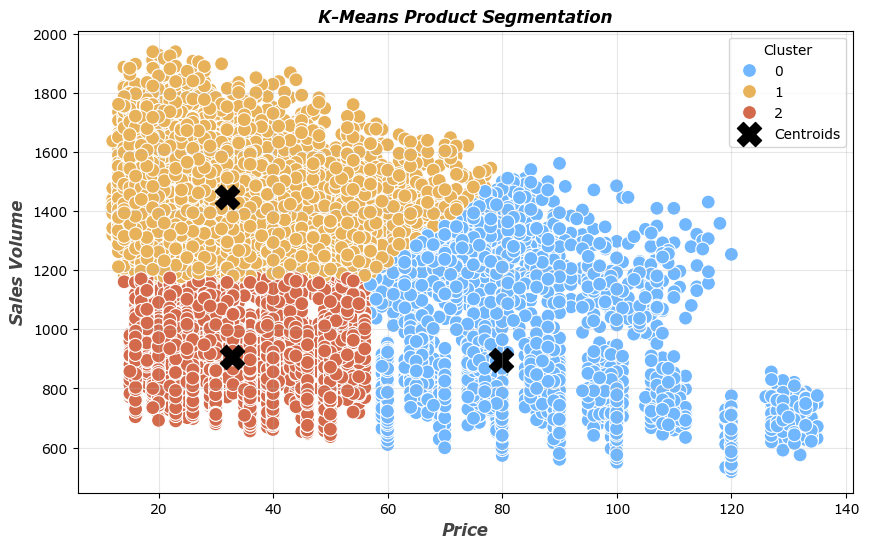

In [47]:
# Visualize the clusters and centroids
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="price",
    y="sales_volume",
    hue="Cluster",
    palette=["#70B7FF", "#E8B25B", "#D46A4C"],
    s=100
)

plt.scatter(
    centroids[:,0],
    centroids[:,1],
    color="black",
    s=300,
    marker="X",
    label="Centroids"
)

plt.title(
    "K-Means Product Segmentation",
    fontsize=12,
    fontweight="bold",
    style="italic"
)

plt.xlabel(
    "Price", 
    fontsize=12, 
    fontweight="bold",
    style="italic",
    color="#434343"
)

plt.ylabel(
    "Sales Volume", 
    fontsize=12, 
    style="italic",
    fontweight="bold",
    color="#434343"
)

plt.grid(alpha=0.3)

plt.legend(title="Cluster")

plt.show()

### Predict

#### Can we predict sales volume and identify which variables have the greatest impact?

In [48]:
# Prepare data for machine learning
df_encoded = pd.get_dummies(df, drop_first=True)

# Define features and target variable
X = df_encoded.drop(["sales_volume", "revenue"], axis=1)
y = df_encoded["sales_volume"]

In [49]:
# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train a Random Forest Regressor
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [50]:
# Evaluate the model
from sklearn.metrics import r2_score, mean_absolute_error

# Make predictions on the test set
preds = model.predict(X_test)

# Evaluate the predictions
r2_score(y_test, preds)
mean_absolute_error(y_test, preds)

58.88569242162429

In [51]:
# Visualize actual vs predicted values
print("R² Score:", r2_score(y_test, preds))
print("MAE:", mean_absolute_error(y_test, preds))

R² Score: 0.9346028199418522
MAE: 58.88569242162429


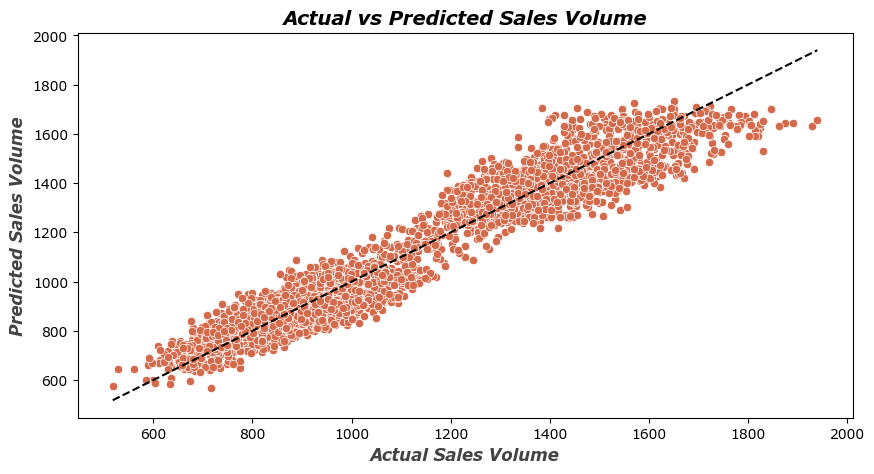

In [52]:
# Acual vs Predicted Sales Volume 
plt.figure(figsize=(10,5))

sns.scatterplot(
    x=y_test,
    y=preds,
    color="#D46A4C"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="black",
    linestyle="--"
)

plt.title(
    "Actual vs Predicted Sales Volume",
    fontsize=14,
    fontweight="bold",
    style="italic",
)

plt.xlabel(
    "Actual Sales Volume", 
    fontsize=12, 
    style="italic",
    fontweight="bold",
    color="#434343"
)
plt.ylabel(
    "Predicted Sales Volume", 
    fontsize=12, 
    style="italic",
    fontweight="bold",
    color="#434343"
)

plt.show()

/var/folders/kw/s6dw9bv10xjcx4tr85g5cjt00000gn/T/ipykernel_3450/2760346918.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


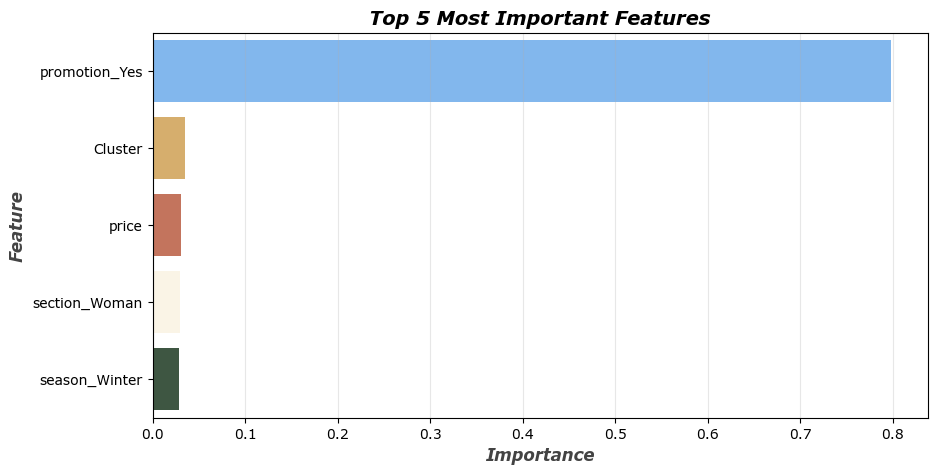

In [53]:
# Display the top 5 most important features
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

# Display the top 5 most important features
plt.figure(figsize=(10,5))

sns.barplot(
    data=feature_importance.head(5),
    x="importance",
    y="feature",
    palette=["#70B7FF", "#E8B25B", "#D46A4C", "#FDF6E3", "#3A5A40"],
)

plt.title(
    "Top 5 Most Important Features",
    fontsize=14,
    fontweight="bold",
    style="italic",
)

plt.xlabel(
    "Importance", 
    fontsize=12, 
    fontweight="bold", 
    style="italic", 
    color="#434343"
)
plt.ylabel(
    "Feature", 
    fontsize=12, 
    fontweight="bold", 
    style="italic", 
    color="#434343"
)

plt.grid(axis="x", alpha=0.3)

plt.show()